In [168]:
import pandas as pd
import datetime as dt
import polars as pl
from trading_engine.core import (
    read_data, create_model_state, orchestrate_model_backtests,
    orchestrate_model_simulations, orchestrate_portfolio_backtests,
    orchestrate_portfolio_simulations
)
from trading_engine.models import MODELS
from trading_engine.optimizers import OPTIMIZERS

from trading_engine.model_state.registry import momentum
from common.constants import ProcessingMode

import datetime

In [169]:
# Define your trading model
from typing import Callable

import polars as pl
from polars import LazyFrame

def MomentumModel(
        trade_ticker: str,
        signal_ticker: str,
        momentum_column: str,
        inverse: bool = True,  # True => long when signal < 0, else flat
        threshold: float = 0.0,  # optional dead-band around 0 to avoid noise
) -> Callable[[LazyFrame], LazyFrame]:
    """
    Generate weights for `trade_ticker` from the momentum of `signal_ticker`.

    inverse=True  -> long when momentum(signal_ticker) < -threshold, else 0
    inverse=False -> long when momentum(signal_ticker) >  threshold, else 0

    Output columns: ["date", trade_ticker]
    """

    def run_model(lf: LazyFrame) -> LazyFrame:
        # Pull only the signal series (lazy)
        sig = (
            lf.filter(pl.col("ticker") == signal_ticker)
            .select([
                pl.col("date"),
                pl.col(momentum_column).alias("sig")
            ])
        )

        # Condition: long when (sig < -threshold) if inverse else (sig > threshold)
        cond = (pl.col("sig") < -threshold) if inverse else (pl.col("sig") > threshold)

        # Vectorized mapping to {1.0, 0.0}; treat null as False via fill_null(False)
        weights = sig.select([
            pl.col("date"),
            pl.when(cond.fill_null(False))
            .then(pl.lit(1.0))
            .otherwise(pl.lit(0.0))
            .cast(pl.Float64)
            .alias(trade_ticker)
        ])

        return weights  # LazyFrame

    return run_model

In [170]:
models_registry = {
    "AMMASPY10": {
        "tickers": ["SPY-US"],  # define the tickers your model looks at
        "columns": ["close_momentum_10"],  # define the model state columns your model needs
        "function": MomentumModel(
            trade_ticker="SPY-US",
            signal_ticker="SPY-US",
            momentum_column="close_momentum_10",
            inverse=False,
        ),
    },
    "AMMASPY20": {
        "tickers": ["SPY-US"],  # define the tickers your model looks at
        "columns": ["close_momentum_20"],  # define the model state columns your model needs
        "function": MomentumModel(
            trade_ticker="SPY-US",
            signal_ticker="SPY-US",
            momentum_column="close_momentum_20",
            inverse=False,
        ),
    },
    "AMMASPY60": {
        "tickers": ["SPY-US"],  # define the tickers your model looks at
        "columns": ["close_momentum_60"],  # define the model state columns your model needs
        "function": MomentumModel(
            trade_ticker="SPY-US",
            signal_ticker="SPY-US",
            momentum_column="close_momentum_60",
            inverse=False,
        ),
    },
    "AMMASPY120": {
        "tickers": ["SPY-US"],  # define the tickers your model looks at
        "columns": ["close_momentum_120"],  # define the model state columns your model needs
        "function": MomentumModel(
            trade_ticker="SPY-US",
            signal_ticker="SPY-US",
            momentum_column="close_momentum_120",
            inverse=False,
        ),
    },
    "AMMASPY240": {
        "tickers": ["SPY-US"],  # define the tickers your model looks at
        "columns": ["close_momentum_240"],  # define the model state columns your model needs
        "function": MomentumModel(
            trade_ticker="SPY-US",
            signal_ticker="SPY-US",
            momentum_column="close_momentum_240",
            inverse=False,
        ),
    },
}

In [171]:
# 1) experiment config
universe = [
  "SPY-US", "SLV-US", "GLD-US", "TLT-US", "USO-US", "UNG-US", "IXJ-US",
  "KXI-US", "JXI-US", "IXG-US", "IXN-US", "RXI-US", "MXI-US", "EXI-US",
  "IXC-US", "IEI-US", "SHY-US", "BIL-US", "JPXN-US", "INDA-US", "MCHI-US",
  "EZU-US", "IBIT-US", "ETHA-US", "VIXY-US"
]
features = ["close_momentum_10","close_momentum_20", "close_momentum_60", "close_momentum_120", "close_momentum_240"]                   # must exist in FEATURES
models   = ["AMMASPY10", "AMMASPY20", "AMMASPY60", "AMMASPY120", "AMMASPY240"]                      # keys in your custom `models_registry`
optimizers   = ["mean_variance"]                # keys in OPTIMIZERS
initial_value = 1_000_000
start_date = datetime.date(2004, 1, 2)
end_date = datetime.date(2025, 9, 10)

In [186]:
# 2) build model state + prices (cached locally)
from trading_engine.core import create_model_state
lf = read_data()
model_state, prices = create_model_state(
    lf=lf,
    features=features,
    start_date=start_date,
    end_date=end_date,
    universe=universe
)

In [173]:
# 3) run model backtests + simulations
model_insights = orchestrate_model_backtests(
    model_state=model_state,
    models=models,
    universe=universe,
    registry=models_registry  # pass in your custom models registry instead of pulling default prod registry
)

model_simulations = orchestrate_model_simulations(
    prices=prices,
    model_insights=model_insights
)

keys = list(model_simulations.keys())
print(keys)
print(type(model_simulations))
for i in keys:
    print(model_simulations[i]['backtest_metrics'])
print()
for i in keys:
    print(model_simulations[i]['backtest_weights'].select('SPY-US'))

['AMMASPY10', 'AMMASPY20', 'AMMASPY60', 'AMMASPY120', 'AMMASPY240']
<class 'dict'>
shape: (20, 2)
┌────────────────────────────────┬──────────────┐
│ metric                         ┆ value        │
│ ---                            ┆ ---          │
│ str                            ┆ f64          │
╞════════════════════════════════╪══════════════╡
│ total_return                   ┆ 1.756136     │
│ annualized_return              ┆ 0.047931     │
│ annualized_volatility          ┆ 0.111022     │
│ sharpe_ratio                   ┆ 0.431725     │
│ sortino_ratio                  ┆ 0.322556     │
│ …                              ┆ …            │
│ num_weight_events              ┆ 5457.0       │
│ parsing_time_ms                ┆ 96.0         │
│ simulation_time_ms             ┆ 28.0         │
│ total_time_ms                  ┆ 124.0        │
│ simulation_speed_dates_per_sec ┆ 192179.18411 │
└────────────────────────────────┴──────────────┘
shape: (20, 2)
┌────────────────────────────────┬───

In [174]:
# 4) optimize portfolio and simulate
portfolio_insights = orchestrate_portfolio_backtests(
    model_insights=model_insights,
    backtest_results=model_simulations,
    universe=universe,
    optimizers=optimizers,
    registry=OPTIMIZERS
)

portfolio_simulations = orchestrate_portfolio_simulations(
    prices=prices,
    portfolio_insights=portfolio_insights
)

[0.         0.         0.98888462 0.         0.01111538]


In [175]:
# 5) visualize one result (example: equal_weight)
portfolio_simulations["mean_variance"]["backtest_metrics"]

metrics = portfolio_simulations["mean_variance"]["backtest_metrics"]

# If it's LazyFrame, collect it first
if hasattr(metrics, "collect"):
    metrics = metrics.collect()

# Show the whole thing
print(metrics)

shape: (20, 2)
┌────────────────────────────────┬───────────────┐
│ metric                         ┆ value         │
│ ---                            ┆ ---           │
│ str                            ┆ f64           │
╞════════════════════════════════╪═══════════════╡
│ total_return                   ┆ 4.745647      │
│ annualized_return              ┆ 0.084091      │
│ annualized_volatility          ┆ 0.110128      │
│ sharpe_ratio                   ┆ 0.763571      │
│ sortino_ratio                  ┆ 0.665983      │
│ …                              ┆ …             │
│ num_weight_events              ┆ 5457.0        │
│ parsing_time_ms                ┆ 29.0          │
│ simulation_time_ms             ┆ 17.0          │
│ total_time_ms                  ┆ 46.0          │
│ simulation_speed_dates_per_sec ┆ 313694.317678 │
└────────────────────────────────┴───────────────┘


In [176]:
portfolio_simulations["mean_variance"]["backtest_weights"].select(['date',"SPY-US"]).unique()

date,SPY-US
str,f64
"""2014-01-21""",1.0
"""2010-01-08""",1.0
"""2006-12-11""",1.0
"""2021-11-04""",1.0
"""2019-06-20""",1.0
…,…
"""2018-02-06""",1.0
"""2016-09-22""",1.0
"""2007-08-22""",0.011115


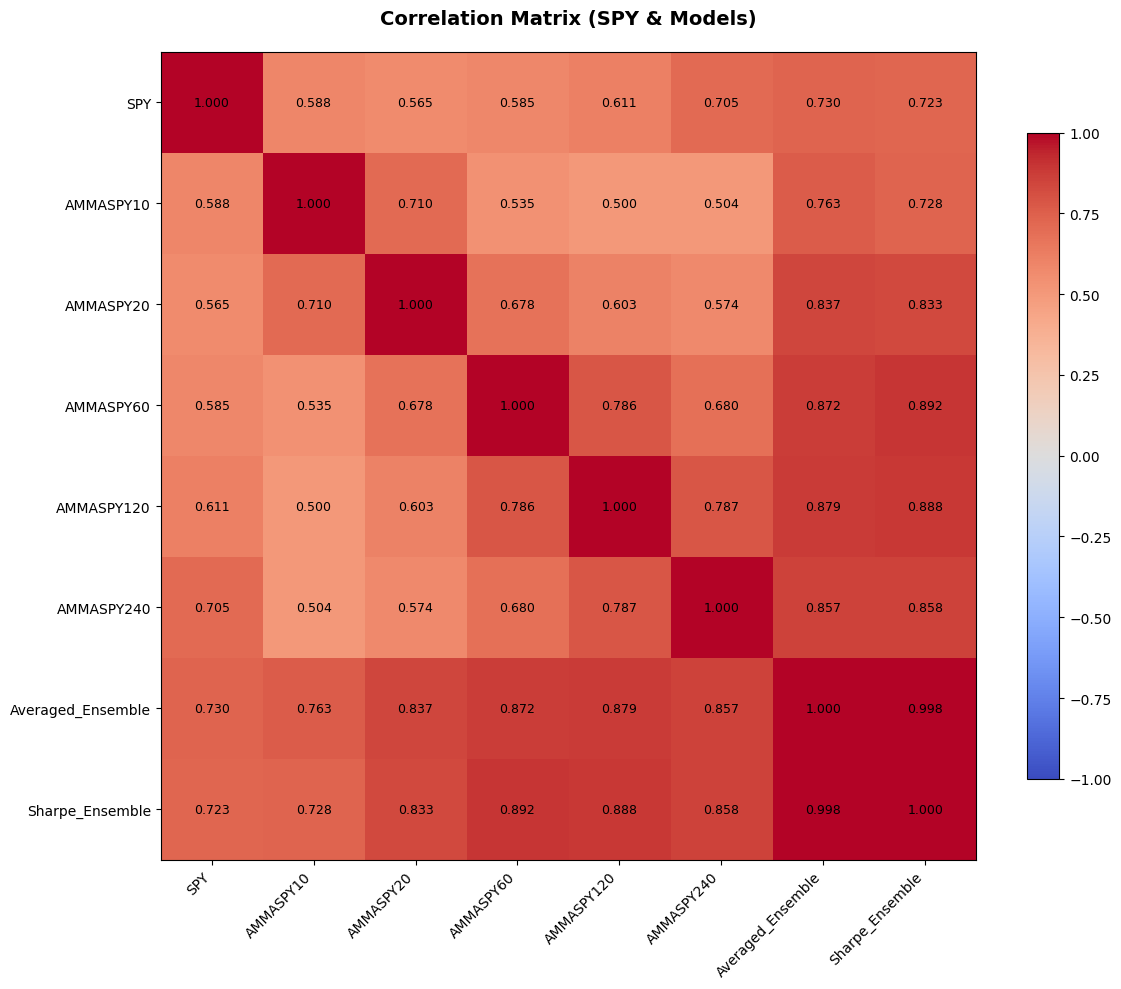


Correlation with SPY:
AMMASPY10           :   0.588
AMMASPY20           :   0.565
AMMASPY60           :   0.585
AMMASPY120          :   0.611
AMMASPY240          :   0.705
Averaged_Ensemble   :   0.730
Sharpe_Ensemble     :   0.723

Averaged ensemble: Combining two models
Sharpe-weighted ensemble: Weighing the combination of two models with sharpe


In [177]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ["AMMASPY10", "AMMASPY20", "AMMASPY60", "AMMASPY120", "AMMASPY240"]

# --- Base SPY returns ---
base_data = (
    prices_df
    .select(['date', 'SPY-US'])
    .sort('date')
    .with_columns([
        pl.col('SPY-US').pct_change().alias('SPY')
    ])
    .select(['date', 'SPY'])
)

all_returns = {'SPY': base_data}

# --- Individual model returns ---
for model_name in model_names:
    weights_df = model_simulations[model_name]['backtest_weights']
    if hasattr(weights_df, 'collect'):
        weights_df = weights_df.collect()
    
    model_data = (
        prices_df
        .select(['date', 'SPY-US'])
        .join(weights_df.select(['date', 'SPY-US']).rename({'SPY-US': 'signal'}), on='date', how='inner')
        .sort('date')
        .with_columns([
            pl.col('SPY-US').pct_change().alias('daily_return')
        ])
        .with_columns([
            (pl.col('signal').shift(1) * pl.col('daily_return')).alias(model_name)
        ])
        .select(['date', model_name])
    )
    all_returns[model_name] = model_data

# --- Averaged ensemble ---
all_signals = []
for model_name in model_names:
    weights_df = model_simulations[model_name]['backtest_weights']
    if hasattr(weights_df, 'collect'):
        weights_df = weights_df.collect()
    weights_df = weights_df.select(['date', 'SPY-US']).rename({'SPY-US': model_name})
    all_signals.append(weights_df)

aggregated = all_signals[0]
for df in all_signals[1:]:
    aggregated = aggregated.join(df, on='date', how='inner')

# average signal
aggregated = aggregated.with_columns([
    sum(pl.col(m) for m in model_names).alias('avg_signal') / len(model_names)
])

avg_ensemble = (
    prices_df
    .select(['date', 'SPY-US'])
    .join(aggregated.select(['date', 'avg_signal']), on='date', how='inner')
    .sort('date')
    .with_columns([
        pl.col('SPY-US').pct_change().alias('daily_return')
    ])
    .with_columns([
        (pl.col('avg_signal').shift(1) * pl.col('daily_return')).alias('Averaged_Ensemble')
    ])
    .select(['date', 'Averaged_Ensemble'])
)

all_returns['Averaged_Ensemble'] = avg_ensemble

# --- Sharpe-weighted ensemble ---
sharpe_ratios = {}
for model_name in model_names:
    metrics = model_simulations[model_name]['backtest_metrics']
    sharpe = metrics.filter(pl.col('metric') == 'sharpe_ratio')['value'][0]
    sharpe_ratios[model_name] = max(0.0, sharpe)

total_sharpe = sum(sharpe_ratios.values())
if total_sharpe == 0:
    sharpe_weights = {name: 1/len(model_names) for name in model_names}
else:
    sharpe_weights = {name: sharpe / total_sharpe for name, sharpe in sharpe_ratios.items()}

aggregated = aggregated.with_columns([
    sum(pl.col(m) * sharpe_weights[m] for m in model_names).alias('sharpe_signal')
])

sharpe_ensemble = (
    prices_df
    .select(['date', 'SPY-US'])
    .join(aggregated.select(['date', 'sharpe_signal']), on='date', how='inner')
    .sort('date')
    .with_columns([
        pl.col('SPY-US').pct_change().alias('daily_return')
    ])
    .with_columns([
        (pl.col('sharpe_signal').shift(1) * pl.col('daily_return')).alias('Sharpe_Ensemble')
    ])
    .select(['date', 'Sharpe_Ensemble'])
)

all_returns['Sharpe_Ensemble'] = sharpe_ensemble

# --- Combine everything ---
combined = all_returns['SPY']
for key in model_names + ['Averaged_Ensemble', 'Sharpe_Ensemble']:
    combined = combined.join(all_returns[key], on='date', how='inner')

combined = combined.drop_nulls()

# --- Correlation matrix ---
columns = ['SPY'] + model_names + ['Averaged_Ensemble', 'Sharpe_Ensemble']
corr_data = [combined[col].to_list() for col in columns]
corr_matrix = np.corrcoef(corr_data)

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(np.arange(len(columns)))
ax.set_yticks(np.arange(len(columns)))
ax.set_xticklabels(columns, rotation=45, ha='right')
ax.set_yticklabels(columns)
for i in range(len(columns)):
    for j in range(len(columns)):
        ax.text(j, i, f'{corr_matrix[i, j]:.3f}', ha="center", va="center", color="black", fontsize=9)
ax.set_title('Correlation Matrix (SPY & Models)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# --- Print SPY correlations ---
print("\nCorrelation with SPY:")
for i, col in enumerate(columns[1:], 1):
    print(f"{col:20s}: {corr_matrix[0, i]:>7.3f}")
print()
print("Averaged ensemble: Combining two models")
print("Sharpe-weighted ensemble: Weighing the combination of two models with sharpe")

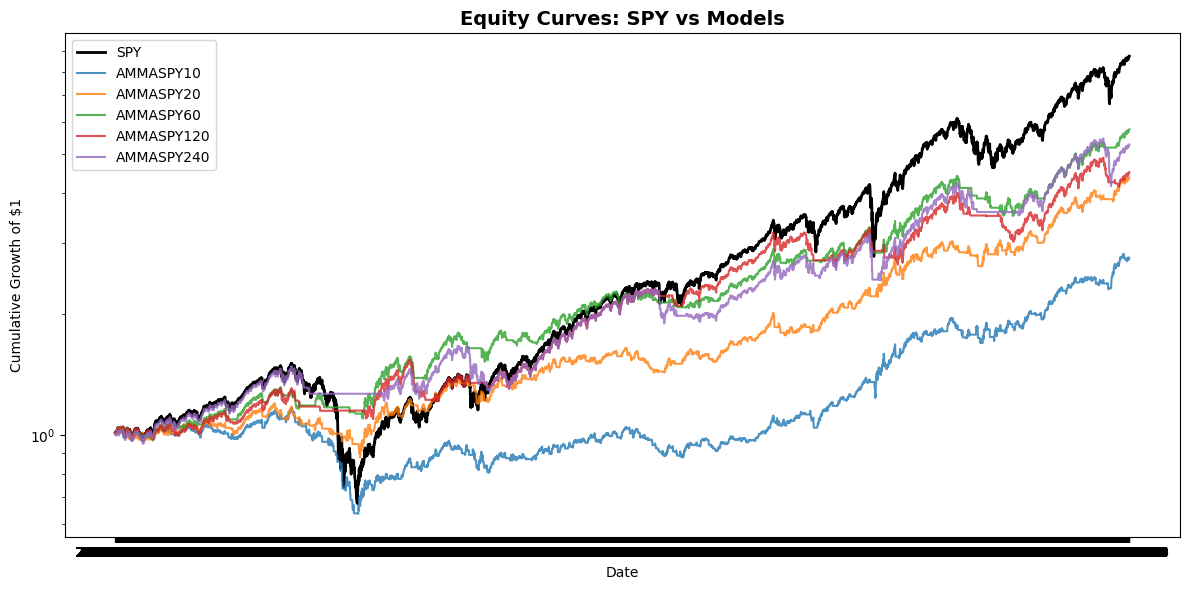

In [178]:
def build_equity_curve(prices_df: pl.DataFrame, model_simulations: dict, model_names: list):
    """
    Build equity curves for SPY and given models.
    """
    # --- SPY baseline ---
    spy = (
        prices_df
        .select(['date', 'SPY-US'])
        .sort('date')
        .with_columns([
            pl.col('SPY-US').pct_change().alias('daily_return')
        ])
        .with_columns([
            (1 + pl.col('daily_return')).cum_prod().alias('SPY_Equity')
        ])
        .select(['date', 'SPY_Equity'])
    )

    # --- Models ---
    curves = {'SPY': spy}
    for model in model_names:
        weights_df = model_simulations[model]['backtest_weights']
        if hasattr(weights_df, 'collect'):
            weights_df = weights_df.collect()

        model_curve = (
            prices_df
            .select(['date', 'SPY-US'])
            .join(weights_df.select(['date', 'SPY-US']).rename({'SPY-US': 'signal'}), on='date', how='inner')
            .sort('date')
            .with_columns([
                pl.col('SPY-US').pct_change().alias('daily_return')
            ])
            .with_columns([
                (pl.col('signal').shift(1) * pl.col('daily_return')).alias('model_return')
            ])
            .with_columns([
                (1 + pl.col('model_return')).cum_prod().alias(model + "_Equity")
            ])
            .select(['date', model + "_Equity"])
        )
        curves[model] = model_curve

    # --- Combine all into one frame ---
    combined = spy
    for model in model_names:
        combined = combined.join(curves[model], on='date', how='inner')

    return combined


def plot_equity_curves(combined: pl.DataFrame, model_names: list):
    """
    Plot SPY and model equity curves on one chart.
    """
    plt.figure(figsize=(12, 6))
    
    # SPY
    plt.plot(combined['date'], combined['SPY_Equity'], label='SPY', linewidth=2, color='black')
    
    # Models
    for model in model_names:
        plt.plot(combined['date'], combined[model + "_Equity"], label=model, alpha=0.8)

    plt.title("Equity Curves: SPY vs Models", fontsize=14, fontweight="bold")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Growth of $1")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()


# --- Usage ---
model_names = ["AMMASPY10", "AMMASPY20", "AMMASPY60", "AMMASPY120", "AMMASPY240"]

equity_curves = build_equity_curve(prices, model_simulations, model_names)
plot_equity_curves(equity_curves, model_names)

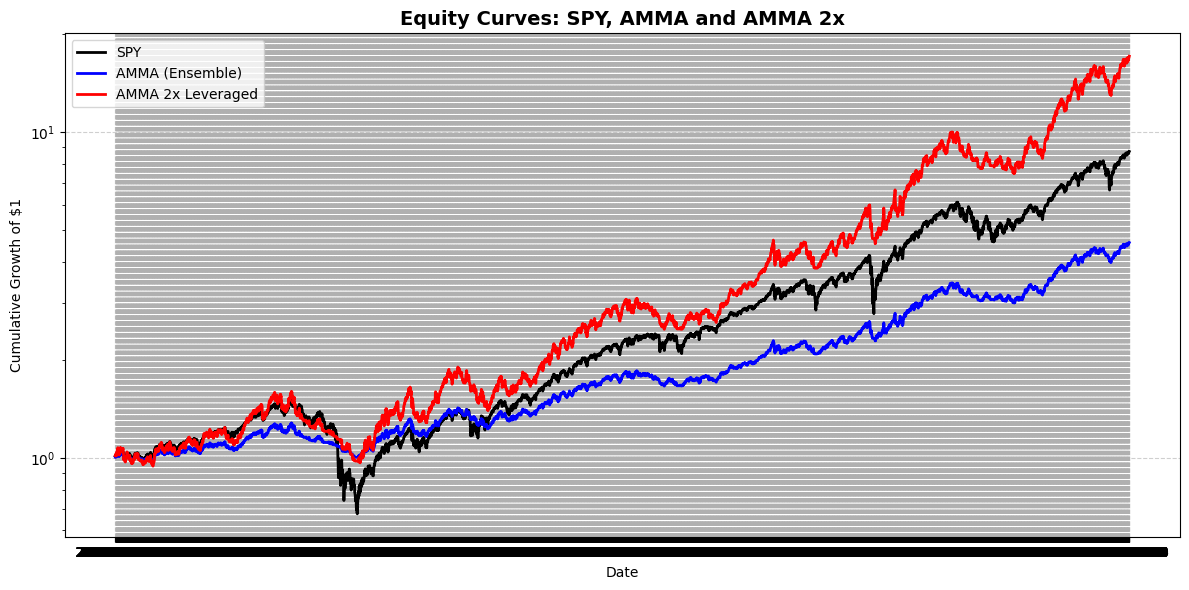

In [179]:

"""
Build and plot AMMA (ensemble), AMMA 2x leveraged, and SPY equity curves.
"""
# average of model returns
model_cols = [m for m in model_names]  # use existing model return columns
model_returns = [combined[c].fill_null(0) for c in model_cols]  # returns should already be pct_change
avg_return = sum(model_returns) / len(model_returns)

# SPY equity
spy_return = combined['SPY'].fill_null(0)
spy_equity = (1 + spy_return).cum_prod()

# equity curves
amma_equity = (1 + avg_return).cum_prod()
amma2x_equity = (1 + avg_return * 2).cum_prod()

# --- plot ---
plt.figure(figsize=(12, 6))
plt.plot(combined['date'], spy_equity, label="SPY", linewidth=2, linestyle="-", color="black")
plt.plot(combined['date'], amma_equity, label="AMMA (Ensemble)", linewidth=2, linestyle="-", color="blue")
plt.plot(combined['date'], amma2x_equity, label="AMMA 2x Leveraged", linewidth=2, linestyle="-", color="red")

plt.title("Equity Curves: SPY, AMMA and AMMA 2x", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.yscale("log")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [180]:
# Model Expected Returns (currently using mean of daily returns, more sophisticated methods can be looked at)
# Model Covariance Matrix (more sophisticated methods can be looked at)
# Utility function (as shown in class): u = w^Tμ - γw^TΣw
# w^Tμ = expected return, γ (gamma) = risk aversion param, Σ (Sigma) = covariance matrix
# Maximize u to solve for the optimal w
 
def MeanVarianceOptimizer(gamma: float = 1.0, lookback: int = 252) -> Callable[[Dict[str, LazyFrame], Dict], LazyFrame]:
    def run(model_insights: Dict[str, LazyFrame], backtest_results: Dict) -> LazyFrame:
        if not model_insights:
            return pl.DataFrame({"date": []}).lazy()
       
        models = list(model_insights.keys())
       
        # Expected returns
        mu = np.array([
            backtest_results[model]["backtest_results"]["daily_return"].mean()
            for model in models
        ])
       
        # Covariance matrix
        daily_returns = [
            backtest_results[model]["backtest_results"]["daily_return"].tail(lookback).to_numpy()    
            for model in models
        ]
        X = np.column_stack(daily_returns)
       
        # Ledoit-Wolf shrinkage
        lw = LedoitWolf()
        Sigma = lw.fit(X).covariance_
        Sigma += np.eye(len(models)) * 1e-6
 
        # Optimization
        w = cp.Variable(len(mu))
        u = mu @ w - gamma * cp.quad_form(w, Sigma)
        obj = cp.Maximize(u)
        constraints = [cp.sum(w) == 1, w >= 0]
        problem = cp.Problem(obj, constraints)
        problem.solve()
       
        # Clean weights
        weights = w.value
        if weights is None or np.any(np.isnan(weights)):
            print(f"Optimization failed, using equal weights.")
            weights = np.ones(len(models)) / len(models)
        else:
            weights = np.maximum(weights, 0)
            weights = weights / weights.sum()
 
        print(weights)
        # Create model weights lookup
        model_weights_lf = pl.DataFrame({
            "model": models,
            "model_weight": weights
        }).lazy()
 
        combined_long_lf = (
            pl.concat([
                lf.unpivot(index="date", variable_name="ticker", value_name="position")
                  .with_columns(pl.lit(model).alias("model"))
                for model, lf in zip(models, model_insights.values())
            ])
            .join(model_weights_lf, on="model", how="left")
            .with_columns((pl.col("position") * pl.col("model_weight")).alias("w"))
            .group_by(["date", "ticker"])
            .agg(pl.col("w").sum())
        )
       
        combined_wide_df = (
            combined_long_lf
            .collect(engine='streaming')  # materialize before pivot
            .pivot(values="w", index="date", on="ticker", aggregate_function="first")
            .sort("date")
        )
       
        return combined_wide_df.lazy()
   
    return run

OPTIMIZERS["mean_variance"] = {
    "function": MeanVarianceOptimizer(gamma=1.0, lookback=252)
}

In [185]:
# Use the averaged ensemble you already built
amma_returns = (
    combined
    .select(["date", "Averaged_Ensemble"])
    .rename({"Averaged_Ensemble": "AMMA_SPY_Returns"})
)

# Fill nulls with 0 (no signal days)
amma_returns = amma_returns.with_columns([
    pl.col("AMMA_SPY_Returns").fill_null(0)
])

# Save to CSV
amma_returns.write_csv("AMMA_returns.csv")

print("Exported: AMMA_returns.csv")

Exported: AMMA_returns.csv
